# A. Jugando con la precision en Python


##1. Complete y depure `suma_seno` (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.

In [ ]:
def suma_seno(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = -term*((x**2)/((2*n)*((2*n)+1)))      # Usa la relación recursiva para calcular el nuevo término a partir del anterior.
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term) < tol*max(1,abs(total)):        # Se usa el criterio de parada mixto basado en term, tol y total.
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1  # Devuelve la aproximación calculada y el número de iteraciones realizadas.

y=suma_seno(3.1416/4) # Se evalua para un x=3.1416/4 para verificar si el programa esta bien hecho
print(y) # Visualesamos el valor de y, ademas se verifico el resultado comparandolo con lo esperado por fuera de este programa.

(0.7071080798525453, 5)


##2. Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de $x$ entre $0$ y $4\pi$, incluyendo el número de iteraciones, la suma y el error relativo frente a `math.sin`.

In [ ]:
import math  # Importa el módulo math para usar la función seno de referencia.


print(f"{'x':>6} {'imax':>6} {'suma':>16} {'error relativo':>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [0.6, 1.5, 2.8, 3.4, 6.2,7.3]:  # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")  # Imprime una fila de la tabla con formato numérico.

     x   imax             suma   error relativo
  0.60      5     0.5646424734         3.71e-13
  1.50      7     0.9974949866         2.76e-12
  2.80      9     0.3349881501         1.41e-10
  3.40     10    -0.2555411020         2.49e-10
  6.20     15    -0.0830894028         1.89e-10
  7.30     16     0.8504366208         1.80e-10


##3. Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada $10^{-8}$: ¿en todos los valores de $x$ que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de $x$ ocurre y explique a qué se debe.


$R//$ Como se puede observar, el error relativo de todos los valores probados estubieron por debajo de la tolerancia, esto se confirma debido a que el mismo esta elevado como minimo a e-10, lo que esta por debajo de 1e-8, cuyo es el valor de la tolerancia.

##4. Repita el experimento de la sección 7 para $x$ grande (por ejemplo, $x=100$) **sin** la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.

In [ ]:

y=suma_seno(100) # Se evalua para un x=3.1416/4 para verificar si el programa esta bien hecho
print(y) # Visualesamos el valor de y, ademas se verifico el resultado comparandolo con lo esperado por fuera de este programa.

(-1.4487149708671258e+26, 111)


Lo que sucede, es que los terminos intermedios se vuelven tan grandes antes que se cancelen que asta la presicion finita del float se le es incapas de representarlos correctamente, haciendo imposible la cancelacion y arrojando como resultado un valor exorvitado e incorrecto.

##5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando `math.factorial` y `x**potencia` — ¿en qué valores de $x$ empieza a notarse la diferencia de desempeño o de precisión?

In [ ]:
import math                                          #Importa el modulo match para usar la funsion factorial
def suma_senobad(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor de manera directa.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = ((-1)**n)*((x**(2*n+1))/(math.factorial(2*n+1)))                                #  Calcula directamente el nuevo termino.
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term) < tol*max(1,abs(total)):                                     # COMPLETAR: escribe el criterio de parada mixto basado en term, tol y total.
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1  # Devuelve la aproximación calculada y el número de iteraciones realizadas.

print(f"{'x':>6} {'imax':>6} {'suma':>16} {'error relativo':>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [-10,0.6, 1.5, 2.8, 3.4, 6.2,7.3,10,11,12,13,40, 60,70]:  # Recorre varios valores
    approx, iters = suma_senobad(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")  # Imprime una fila de la tabla con formato numérico.


     x   imax             suma   error relativo
-10.00     20     0.5440211107         2.90e-10
  0.60      5     0.5646424734         3.71e-13
  1.50      7     0.9974949866         2.76e-12
  2.80      9     0.3349881501         1.41e-10
  3.40     10    -0.2555411020         2.49e-10
  6.20     15    -0.0830894028         1.89e-10
  7.30     16     0.8504366208         1.80e-10
 10.00     20    -0.5440211107         2.90e-10
 11.00     21    -0.9999902071         5.78e-10
 12.00     23    -0.5365729181         2.20e-10
 13.00     24     0.4201670372         9.38e-10
 40.00     61    -3.2822091353         5.40e+00
 60.00     79 -1040182834.6738526821         3.41e+09
 70.00     88 -3164386646710.9008789062         4.09e+12


In [ ]:
print(f"{'x':>6} {'imax':>6} {'suma':>16} {'error relativo':>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [-10,0.6, 1.5, 2.8, 3.4, 6.2,7.3,10,11,12,13,40,60,70]:  # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")  # Imprime una fila de la tabla con formato numérico.

     x   imax             suma   error relativo
-10.00     20     0.5440211107         2.90e-10
  0.60      5     0.5646424734         3.71e-13
  1.50      7     0.9974949866         2.76e-12
  2.80      9     0.3349881501         1.41e-10
  3.40     10    -0.2555411020         2.49e-10
  6.20     15    -0.0830894028         1.89e-10
  7.30     16     0.8504366208         1.80e-10
 10.00     20    -0.5440211107         2.90e-10
 11.00     21    -0.9999902071         5.77e-10
 12.00     23    -0.5365729181         2.19e-10
 13.00     24     0.4201670372         9.40e-10
 40.00     61     1.0697458967         4.36e-01
 60.00     79 307383974.9339748621         1.01e+09
 70.00     87 -10471885713854.2617187500         1.35e+13


En cuestion a la exactitud, con valores entre 0 y 10 no se nota la diferencia , pero con valores mas grandes la inexactitud crece rapidamente para ambas, con la diferencia en que para el metodo ingenuo lo hace mas rapido que para la version recursiva.

En cuestion al desempeño,con valores entre 0 y 10 no se nota la diferencia, pero con valores de 70 en adelante, a la version ingenua le toma hacer mas iteraciones que la version recursiva.

# B. Decaimiento radiactivo con Python (Entregar Reporte)

Durante la semana anterior estudiamos el **decaimiento radiactivo utilizando FORTRAN**. En este ejercicio retomaremos el mismo sistema físico, pero utilizaremos Python para trabajar con un conjunto de valores, analizar los resultados y representarlos gráficamente.

El número de núcleos radiactivos presentes en una muestra evoluciona de acuerdo con

$$
N(t)=N_0e^{-\lambda t},
$$

donde $N_0$ es el número inicial de núcleos y $\lambda$ es la constante de decaimiento. Esta constante se relaciona con la vida media $t_{1/2}$ mediante

$$
\lambda=\frac{\ln(2)}{t_{1/2}}.
$$

Considere una muestra con

$$
N_0=10\,000
$$

núcleos radiactivos y una vida media de

$$
t_{1/2}=5\ \mathrm{años}.
$$



## Actividades


###1. Calcule la constante de decaimiento $\lambda$.

In [2]:
import numpy as np # Importamos numpy para usar la funcion logaritmo natural (log).
t_media=5 # Definimos el tiempo medio.
lamda= np.log(2)/t_media # Con el tiempo medio calulamos lamda .
print('Lamda es igual a',lamda) # Mostramos el resultado obtenido.

Lamda es igual a 0.13862943611198905


###2. Utilice `numpy.linspace()` para crear un arreglo de tiempos entre **0 y 30 años**. Utilice un número suficiente de puntos para observar claramente la evolución de la muestra.

In [3]:
import numpy as np #Importamos numpy para usar la funcion linspace.
t=np.linspace(0,30,100) # Definimos el intervalo de tiempo en que nos piden y la cantidad de puntos que vamos a usar.
print(t) # Mostramos estos mismos para una mayor apreciacion :) .


[ 0.          0.3030303   0.60606061  0.90909091  1.21212121  1.51515152
  1.81818182  2.12121212  2.42424242  2.72727273  3.03030303  3.33333333
  3.63636364  3.93939394  4.24242424  4.54545455  4.84848485  5.15151515
  5.45454545  5.75757576  6.06060606  6.36363636  6.66666667  6.96969697
  7.27272727  7.57575758  7.87878788  8.18181818  8.48484848  8.78787879
  9.09090909  9.39393939  9.6969697  10.         10.3030303  10.60606061
 10.90909091 11.21212121 11.51515152 11.81818182 12.12121212 12.42424242
 12.72727273 13.03030303 13.33333333 13.63636364 13.93939394 14.24242424
 14.54545455 14.84848485 15.15151515 15.45454545 15.75757576 16.06060606
 16.36363636 16.66666667 16.96969697 17.27272727 17.57575758 17.87878788
 18.18181818 18.48484848 18.78787879 19.09090909 19.39393939 19.6969697
 20.         20.3030303  20.60606061 20.90909091 21.21212121 21.51515152
 21.81818182 22.12121212 22.42424242 22.72727273 23.03030303 23.33333333
 23.63636364 23.93939394 24.24242424 24.54545455 24.

###3. Calcule $N(t)$ para todos los valores del arreglo de tiempos utilizando las operaciones vectorizadas de NumPy.

   **No utilice un ciclo `for` para realizar este cálculo.**

In [4]:
import numpy as np # Importamos numpy para usar la funcion logaritmo natural (log).
def Decaiminto_radiac(x): # Definimos la funcion que nos ayudara a calcular el decarimeineto radiactivo con resptecto al tiempo.
  N_o = 10**4 # Definimos la muestra inicial.
  lamda = np.log(2)/5 # Definimos lamda.
  N_t = N_o*(np.e**(-lamda*x)) # Definimoos la operacion con la cual calculamos el numero de nucleos radiactivos.
  return N_t # Devuelve lo calculado.

N_t1=Decaiminto_radiac(t) # Redefinimos a N(t) para no escribir todo ese palabrerio.
print(N_t1) # Mostramos estos mismos para una mayor apreciacion :) .

[10000.          9588.6122746   9194.14853525  8815.91254996
  8453.23672883  8105.48094581  7772.03140885  7452.29957655
  7145.72111937  6851.7549236   6569.8821363   6299.60524947
  6040.44722202  5791.95063771  5553.67689786  5325.2054472
  5106.13303158  4896.07298623  4694.65455331  4501.52222748
  4316.33512848  4138.76639942  3968.50262992  3805.2433029
  3648.7002642   3498.59721397  3354.66921897  3216.66224502
  3084.33270859  2957.44704685  2835.78130549  2719.12074339
  2607.25945362  2500.          2397.15306865  2298.53713381
  2203.97813749  2113.30918221  2026.37023645  1943.00785221
  1863.07489414  1786.43027984  1712.9387309   1642.47053407
  1574.90131237  1510.11180551  1447.98765943  1388.41922447
  1331.3013618   1276.53325789  1224.01824656  1173.66363833
  1125.38055687  1079.08378212  1034.69159986   992.12565748
   951.31082573   912.17506605   874.64930349   838.66730474
   804.16556126   771.08317715   739.36176171   708.94532637
   679.78018585   651.8148

###4. Utilice `matplotlib` para representar gráficamente $N(t)$ en función del tiempo. La gráfica debe incluir:

   - título;
   - nombre de los ejes;
   - unidades;
   - una cuadrícula que facilite la lectura de los resultados.

<function matplotlib.pyplot.show(close=None, block=None)>

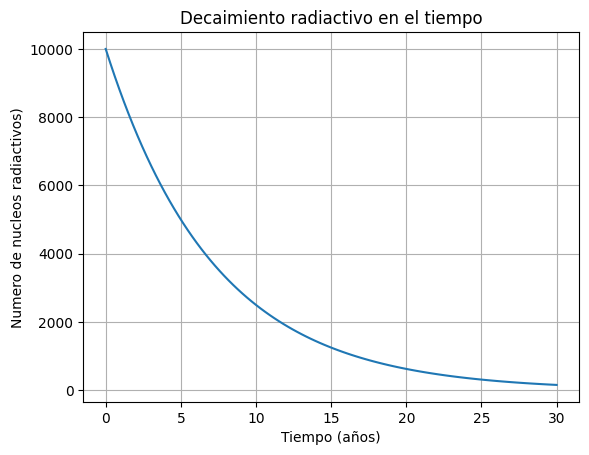

In [5]:
import matplotlib.pyplot as plt # Importamos de matplotilib pyplot para hacer la grafica.
plt.plot(t,N_t1,'-') # Definimos la grafica.
plt.title('Decaimiento radiactivo en el tiempo') # Le colocamos el titulo de la misma a nuestro gusto.
plt.xlabel('Tiempo (años)') # Le asignamos al eje x el tiempo en años.
plt.ylabel('Numero de nucleos radiactivos)') # Le asignamos al eje y el numero de nucleos radiactivos.
plt.grid() # Le decimos que coloque el mayado predeterminado.
plt.show # Mostramos la grafica.

###5. Identifique sobre la gráfica los tiempos correspondientes a **una, dos y tres vidas medias**. Observe qué fracción de la muestra permanece después de cada una de ellas.

 En 5 años el numero de nucleos radiactivos es de  5000.0 , lo que corresponde a 1/2 del inicial
 En 10 años el numero de nucleos radiactivos es de  2500.0000000000005 , lo que corresponde a 1/4 del inicial
 En 15 años el numero de nucleos radiactivos es de  1250.0000000000002 , lo que corresponde a 1/8 del inicial


<function matplotlib.pyplot.show(close=None, block=None)>

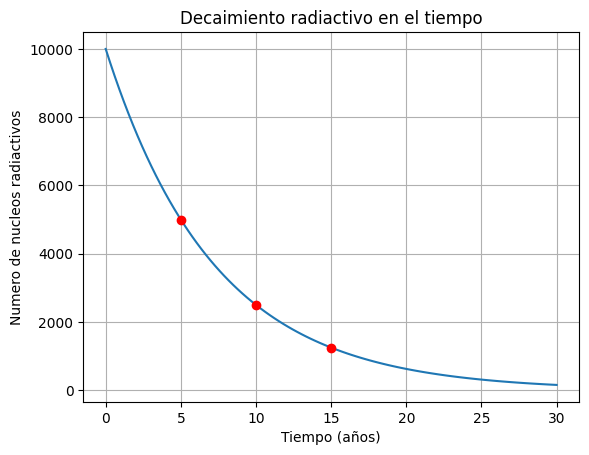

In [6]:
import matplotlib.pyplot as plt # Importamos de matplotilib pyplot para hacer la grafica.
plt.plot(t,N_t1,'-') # Definimos la grafica.
plt.plot(5,Decaiminto_radiac(5),'o',color='red') # Definimos la ubicacion del punto en el que estaria si t fuese la vida media.
plt.plot(10,Decaiminto_radiac(10),'o',color='red') # Definimos la ubicacion del punto en el que estaria si t fuese  dos vecesla vida media.
plt.plot(15,Decaiminto_radiac(15),'o',color='red') # Definimos la ubicacion del punto en el que estaria si t fuese  tres veces la vida media.
plt.title('Decaimiento radiactivo en el tiempo')# Le colocamos el titulo de la misma a nuestro gusto.
plt.xlabel('Tiempo (años)') # Le asignamos al eje x el tiempo en años.
plt.ylabel('Numero de nucleos radiactivos') # Le asignamos al eje y el numero de nucleos radiactivos.
plt.grid() # Le decimos que coloque el mayado predeterminado.

#Imprimimos los resultados t en los tres valores mencionados anteriormente
print(' En 5 años el numero de nucleos radiactivos es de ',Decaiminto_radiac(5),', lo que corresponde a 1/2 del inicial')
print(' En 10 años el numero de nucleos radiactivos es de ',Decaiminto_radiac(10),', lo que corresponde a 1/4 del inicial')
print(' En 15 años el numero de nucleos radiactivos es de ',Decaiminto_radiac(15),', lo que corresponde a 1/8 del inicial')

plt.show # Mostramos la grafica.

###6. Determine aproximadamente el tiempo en el cual permanece:

   - el **50 %** de la muestra inicial;
   - el **25 %** de la muestra inicial;
   - el **10 %** de la muestra inicial.

In [7]:
import numpy as np # Importamos numpy para usar la funcion logaritmo natural (log).

#Calculamos los t pedidos
t1=np.log(1/2)*1/(-lamda)
t2=np.log(1/4)*1/(-lamda)
t3=np.log(1/10)*1/(-lamda)
#Imprimimos los resultados
print('El tiempo en el cual permanece el 50% de la muestra inicial es de ',t1,'años')
print('El tiempo en el cual permanece el 25% de la muestra inicial es de ',t2,'años')
print('El tiempo en el cual permanece el 10% de la muestra inicial es de ',t3,'años')



El tiempo en el cual permanece el 50% de la muestra inicial es de  5.0 años
El tiempo en el cual permanece el 25% de la muestra inicial es de  10.0 años
El tiempo en el cual permanece el 10% de la muestra inicial es de  16.609640474436812 años


# C. Celda de verificación (PASS/FAIL)

Para agilizar la revisión, la tarea debe cerrar con una celda que compruebe automáticamente 2-3 casos conocidos e imprima PASS/FAIL — no hace falta rastrear la lógica a mano para calificar. Abajo hay una celda de verificación para la Parte A (usa `suma_seno_reducida`, ya definida en la sección 7) y una plantilla para la Parte B: complete `N_decaimiento` con $N(t) = N_0 e^{-\lambda t}$ y la celda le dirá si sus resultados coinciden con los valores esperados (recordando el caso de la vida media del carbono-14 de la Semana 1: al cabo de una vida media siempre queda el 50 % de la muestra).

## Para la parte A

In [ ]:
# --- Verificación Parte A: suma_seno_reducida ---
def suma_seno_reducida(x, tol=1e-8, max_iter=200):  # Define una versión que primero reduce el argumento antes de evaluar la serie.
    x_reducido = math.remainder(x, 2 * math.pi)  # Reduce x módulo 2*pi a un intervalo centrado aproximadamente en [-pi, pi].
    suma_seno_reducido= suma_seno(x_reducido, tol, max_iter)  # Evalúa la serie con el argumento reducido.
    return  suma_seno_reducido # Devuelve el resultado.
casos_a = [                                        # Lista de (x, valor_esperado, tolerancia) para probar la Parte A.
    (0.5, math.sin(0.5), 1e-8),                    # Caso dentro del rango normal de convergencia rápida.
    (100.0, math.sin(100.0), 1e-6),                # Caso con x grande: solo debe pasar si se usó reducción de argumento.
    (-237.0, math.sin(-237.0), 1e-6),              # Caso con x grande y negativo.
]

for x, esperado, tol in casos_a:                   # Recorre cada caso de prueba uno por uno.
    obtenido, _ = suma_seno_reducida(x)             # Calcula sin(x) con la función que el estudiante debe haber completado.
    ok = abs(obtenido - esperado) < tol             # Compara contra el valor de referencia dentro de la tolerancia.
    estado = "PASS" if ok else "FAIL"               # Traduce el resultado booleano a texto legible.
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10f}   esperado={esperado: .10f}")  # Imprime el veredicto de este caso.

PASS  x=     0.5   obtenido= 0.4794255386   esperado= 0.4794255386
PASS  x=   100.0   obtenido=-0.5063656411   esperado=-0.5063656411
PASS  x=  -237.0   obtenido= 0.9819578697   esperado= 0.9819578698


##Para la parte B

In [11]:
# --- Parte B: complete N_decaimiento y luego corra la verificación ---
def Decaiminto_radiac(x):
  N_o = 10**4
  lamda = np.log(2)/5
  N_t = N_o*(np.e**(-lamda*x))
  return N_t
casos_b = [                                        # Lista de (t, fracción_esperada): fracción de N0 que debería quedar en cada instante.
    (0.0, 1.00),                                   # En t=0 debe quedar el 100% de la muestra.
    (5.0, 0.50),                                   # En t = t_1/2 (una vida media) debe quedar el 50%.
    (10.0, 0.25),                                  # En t = 2*t_1/2 (dos vidas medias) debe quedar el 25%.
]

for t, fraccion_esperada in casos_b:               # Recorre cada caso de prueba.
    try:                                           # Evita que un NotImplementedError detenga toda la celda de verificación.
        obtenido = Decaiminto_radiac(t) / 10000        # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada con tolerancia razonable.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
        print('Error porcentual de',((obtenido-fraccion_esperada)/fraccion_esperada)*100,'%')
    except NotImplementedError as e:               # Si aún no se ha completado la función, lo informa sin detener la celda.
        print(f"FAIL  t={t:>5.1f} años   ({e})")


PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
Error porcentual de 0.0 %
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
Error porcentual de 0.0 %
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250
Error porcentual de 2.220446049250313e-14 %
